Saving ecommerce_dataset.xlsx to ecommerce_dataset (1).xlsx
First 5 Rows
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagr

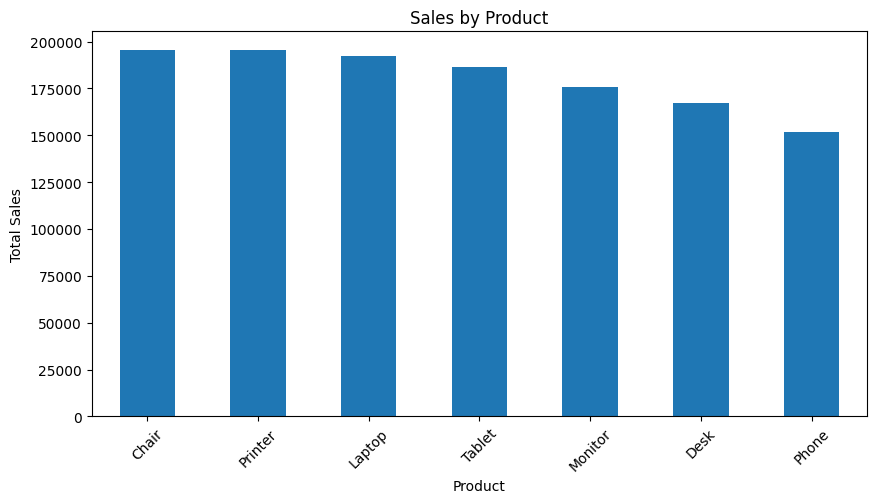

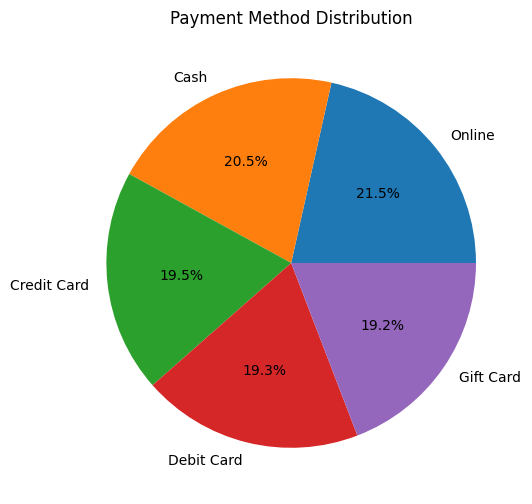

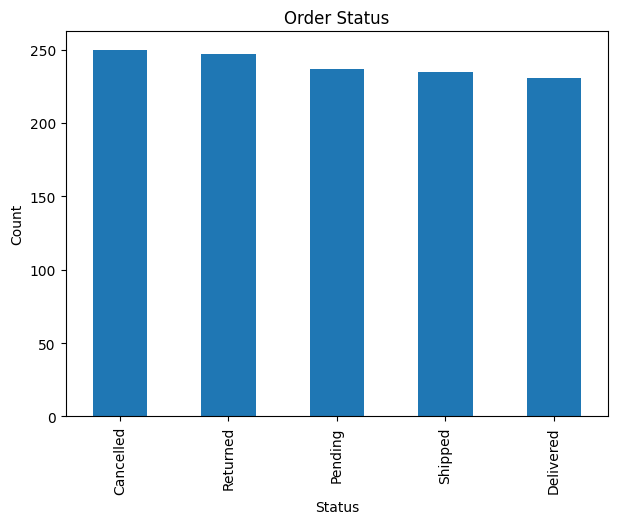

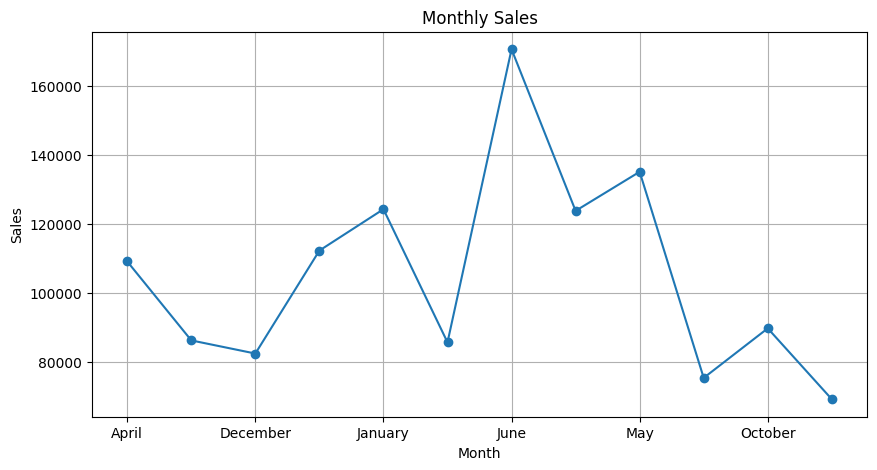

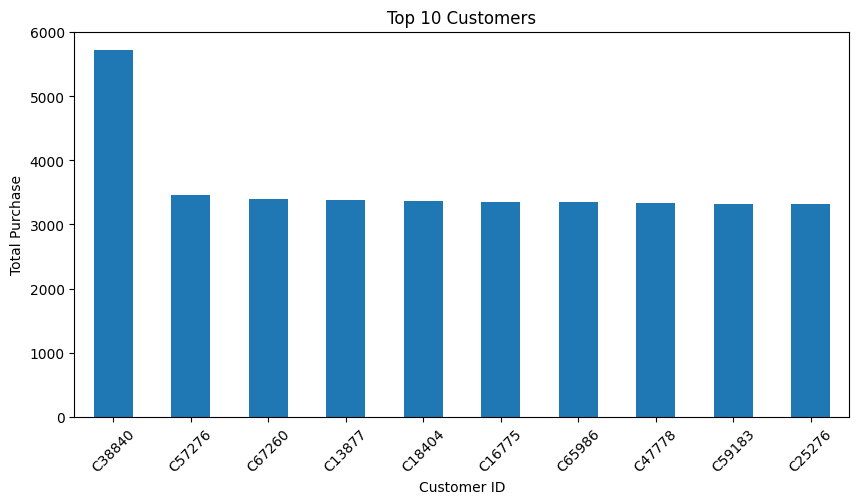

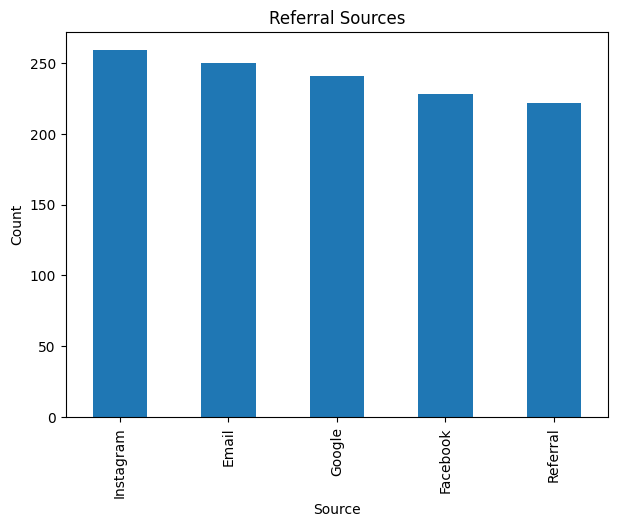

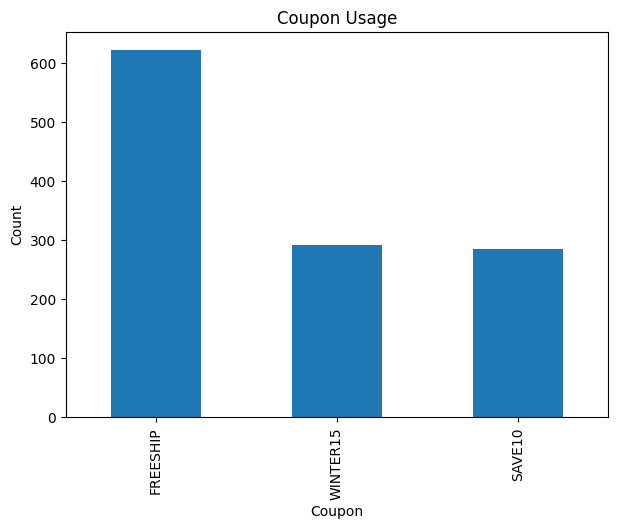

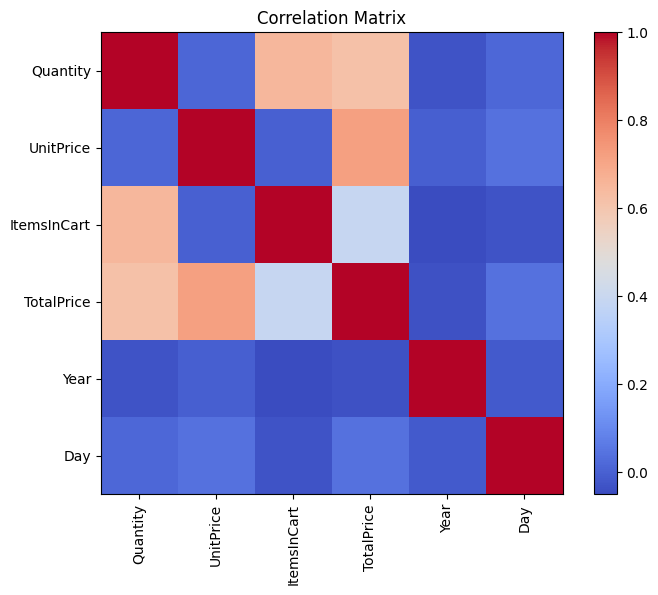


Project Completed Successfully!
Cleaned dataset saved as Cleaned_Project1_Dataset.xlsx


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload Dataset
from google.colab import files
uploaded = files.upload()

# Read Dataset
df = pd.read_excel('/content/ecommerce_dataset.xlsx')

# ==========================================
# Basic Information
# ==========================================
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

# ==========================================
# Data Cleaning
# ==========================================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill Missing Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# ==========================================
# Feature Engineering
# ==========================================

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day

# ==========================================
# Descriptive Statistics
# ==========================================

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# Total Sales
# ==========================================

print("\nTotal Sales =", df['TotalPrice'].sum())

# ==========================================
# Sales by Product
# ==========================================

product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_sales.plot(kind='bar')
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# Payment Method Analysis
# ==========================================

payment = df['PaymentMethod'].value_counts()

plt.figure(figsize=(6,6))
payment.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Payment Method Distribution")
plt.show()

# ==========================================
# Order Status
# ==========================================

status = df['OrderStatus'].value_counts()

plt.figure(figsize=(7,5))
status.plot(kind='bar')
plt.title("Order Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# ==========================================
# Monthly Sales
# ==========================================

monthly = df.groupby('Month')['TotalPrice'].sum()

monthly.plot(figsize=(10,5), marker='o')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# ==========================================
# Top 10 Customers
# ==========================================

top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title("Top 10 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Purchase")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# Referral Source
# ==========================================

referral = df['ReferralSource'].value_counts()

plt.figure(figsize=(7,5))
referral.plot(kind='bar')
plt.title("Referral Sources")
plt.xlabel("Source")
plt.ylabel("Count")
plt.show()

# ==========================================
# Coupon Usage
# ==========================================

coupon = df['CouponCode'].value_counts()

plt.figure(figsize=(7,5))
coupon.plot(kind='bar')
plt.title("Coupon Usage")
plt.xlabel("Coupon")
plt.ylabel("Count")
plt.show()

# ==========================================
# Correlation
# ==========================================

numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

# ==========================================
# Save Cleaned Dataset
# ==========================================

df.to_excel("Cleaned_Project1_Dataset.xlsx", index=False)

print("\nProject Completed Successfully!")
print("Cleaned dataset saved as Cleaned_Project1_Dataset.xlsx")